In [9]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import joypy
import warnings
warnings.filterwarnings("ignore")

In [10]:
df= sns.load_dataset("penguins")

### Penguins Dataset — 20 EDA Questions

1. Species distribution across the three islands  
2. Longest average flipper length by species  
3. Male vs Female body mass comparison  
4. Body mass variation across islands  
5. Correlation between bill length and flipper length  
6. Species with highest variance in body mass  
7. Gentoo vs Adelie bill depth difference  
8. Island hosting heaviest penguins  
9. Linear relationship between flipper length & body mass  
10. Best measurement to separate species  
11. Overlap in bill dimensions across species  
12. Species with smallest average body mass  
13. Flipper length variability vs bill length  
14. Scatterplots for clustering by species  
15. Histograms of body mass (multimodal?)  
16. Correlation between bill length & body mass    
18. Violin plots for Adelie vs Chinstrap  
19. Island with most diverse species mix  
20. Sex distribution differences across species  


In [11]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [15]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [16]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [17]:
# 1 Species distribution across the three islands
df["island"].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

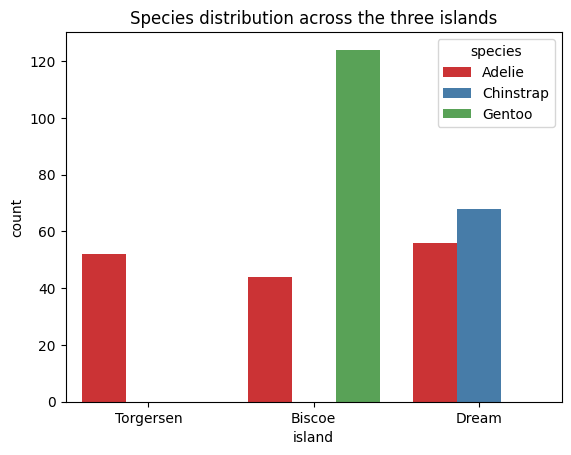

In [21]:
sns.countplot(data=df,x="island",hue="species",palette="Set1")
plt.title("Species distribution across the three islands")
plt.show()

In [33]:
# 2 Longest average flipper length by species


In [25]:
c=df.groupby("species")["flipper_length_mm"].mean().reset_index()
c

,species,flipper_length_mm
0,Adelie,189.953642
1,Chinstrap,195.823529
2,Gentoo,217.186992


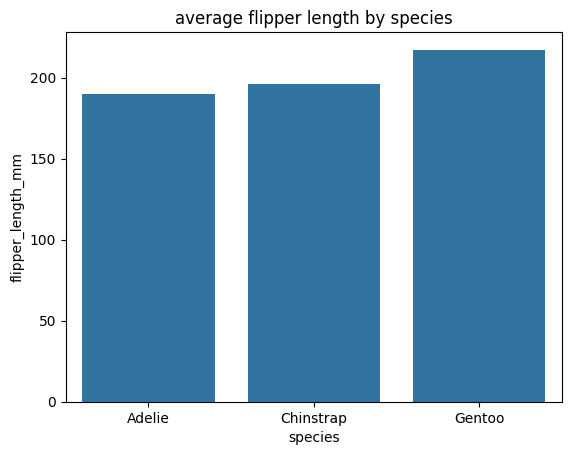

In [31]:
sns.barplot(data=c,x='species',y="flipper_length_mm")
plt.title("average flipper length by species")
plt.show()

In [32]:
# 3 Male vs Female body mass comparison
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


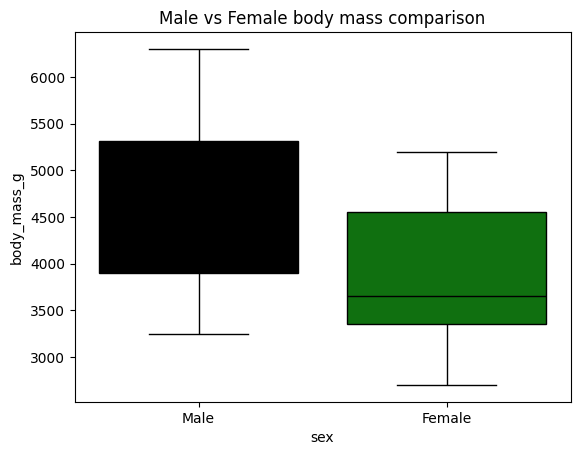

In [43]:
sns.boxplot(data=df,x="sex",y="body_mass_g",palette=["black","green"])
plt.title("Male vs Female body mass comparison")
plt.show()

In [44]:
# 4 Correlation between bill length and flipper length
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


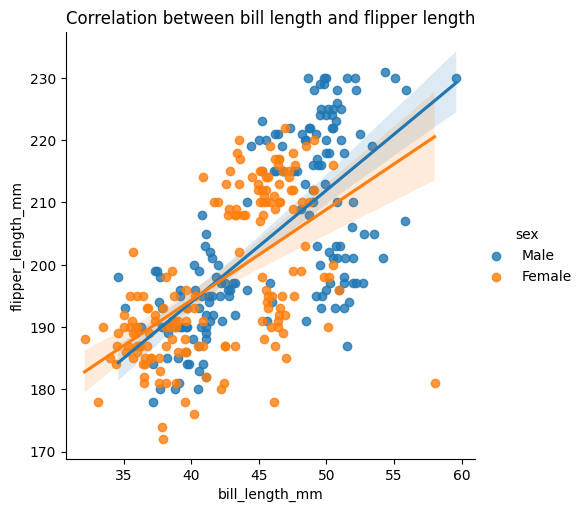

In [49]:
sns.lmplot(data=df,x="bill_length_mm",y="flipper_length_mm",hue="sex")
plt.title("Correlation between bill length and flipper length")
plt.show()


In [50]:
# 6 Species with highest variance in body mass
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [51]:
c=df.groupby("species")['body_mass_g'].mean().reset_index()
c

,species,body_mass_g
0,Adelie,3700.662252
1,Chinstrap,3733.088235
2,Gentoo,5076.016260


In [56]:
c.sort_values("species",ascending=False)

,species,body_mass_g
2,Gentoo,5076.016260
1,Chinstrap,3733.088235
0,Adelie,3700.662252


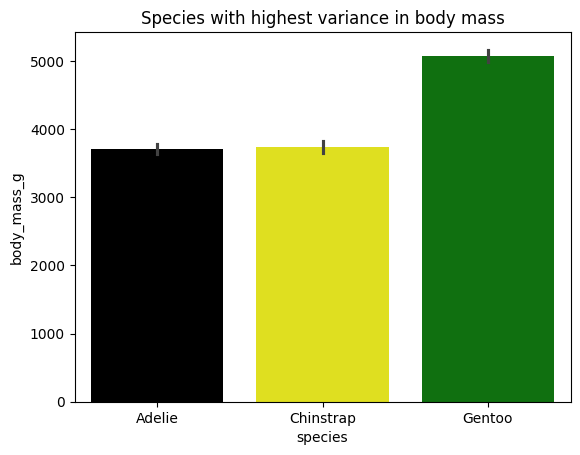

In [59]:
sns.barplot(data=df,x="species",y="body_mass_g",palette=["black","yellow","green"])
plt.title("Species with highest variance in body mass")
plt.show()

In [60]:
# 7 Gentoo vs Adelie bill depth difference
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [65]:
d=df["species"].value_counts().reset_index()
d

,species,count
0,Adelie,152
1,Gentoo,124
2,Chinstrap,68


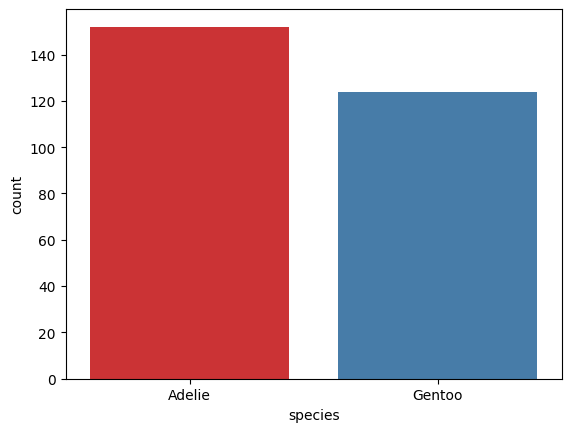

In [69]:
sns.barplot(data=d[d['species'].isin(["Adelie","Gentoo"])],x="species",y="count",palette="Set1")
plt.show()

In [70]:
# 8 Island hosting heaviest penguins
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [77]:
e=df.groupby("island")["body_mass_g"].mean().reset_index()
e

,island,body_mass_g
0,Biscoe,4716.017964
1,Dream,3712.903226
2,Torgersen,3706.372549


In [80]:
e.sort_values("body_mass_g",ascending=False)

,island,body_mass_g
0,Biscoe,4716.017964
1,Dream,3712.903226
2,Torgersen,3706.372549


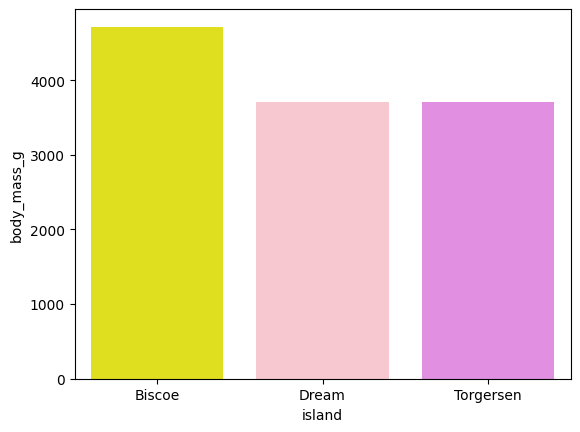

In [82]:
sns.barplot(data=e,x='island',y="body_mass_g",palette=("yellow","pink","violet"))
plt.show()

In [83]:
# 9 Linear relationship between flipper length & body mass
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


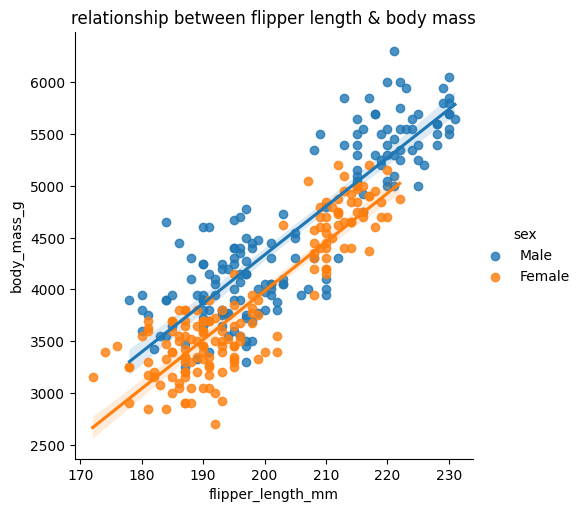

In [84]:
sns.lmplot(data=df,x="flipper_length_mm",y="body_mass_g",hue="sex")
plt.title("relationship between flipper length & body mass")
plt.show()

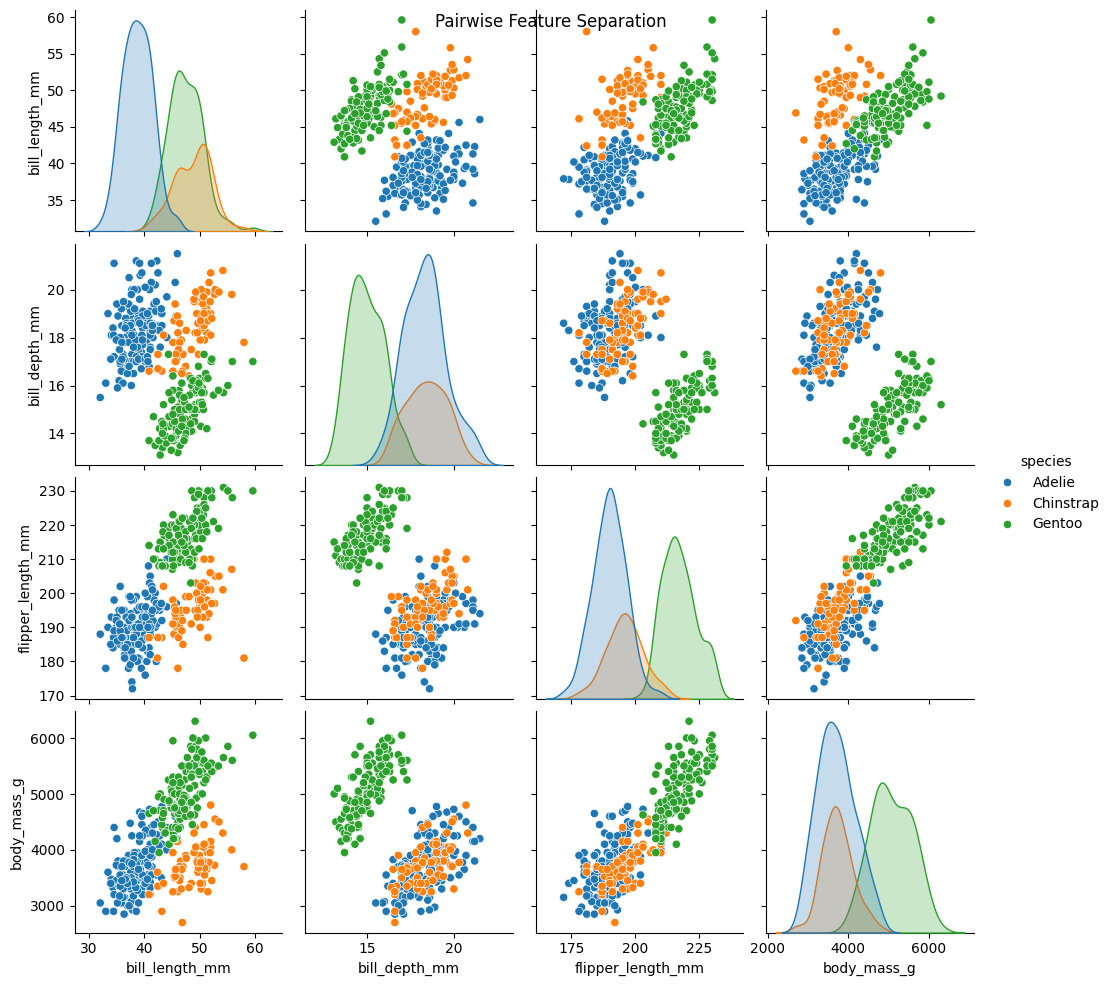

In [86]:
# Q10 Best measurement to separate species
sns.pairplot(df, hue="species")
plt.suptitle("Pairwise Feature Separation")
plt.show()

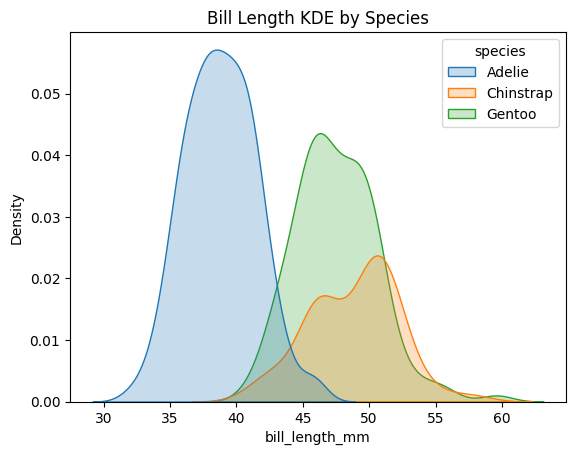

In [88]:
# Q11: Overlap in bill dimensions across species
sns.kdeplot(data=df, x="bill_length_mm", hue="species", fill=True)
plt.title("Bill Length KDE by Species")
plt.show()

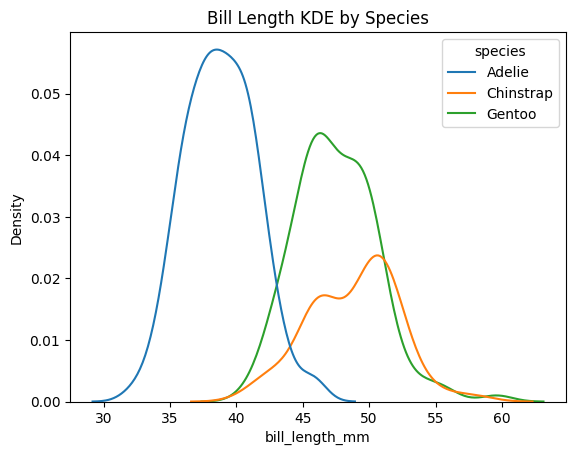

In [90]:
# Q13: Flipper length variability vs bill length
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<Axes: xlabel='species', ylabel='flipper_length_mm'>

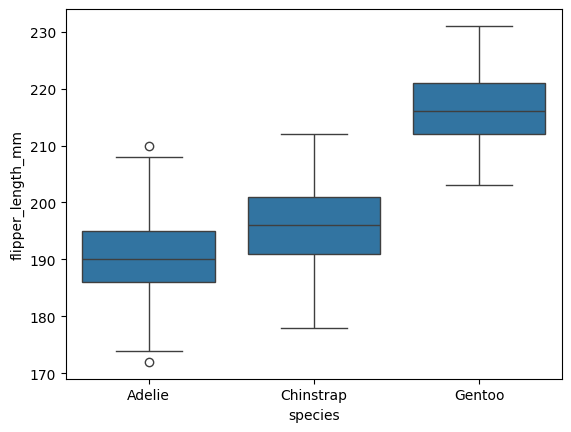

In [98]:
sns.boxplot(data=df,x="species",y="flipper_length_mm")

In [99]:
# Scatterplots for clustering by species
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


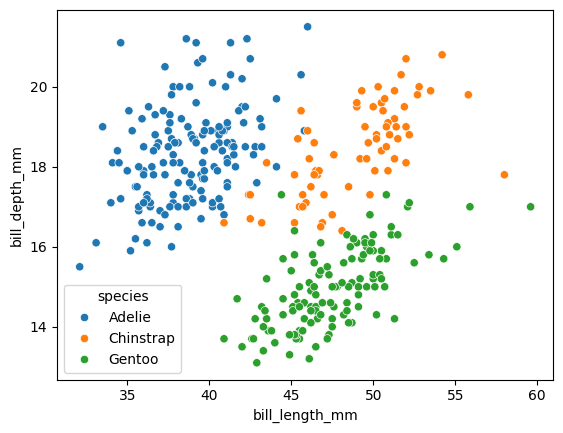

In [103]:
sns.scatterplot(data=df,x="bill_length_mm",y="bill_depth_mm",hue="species")
plt.show()

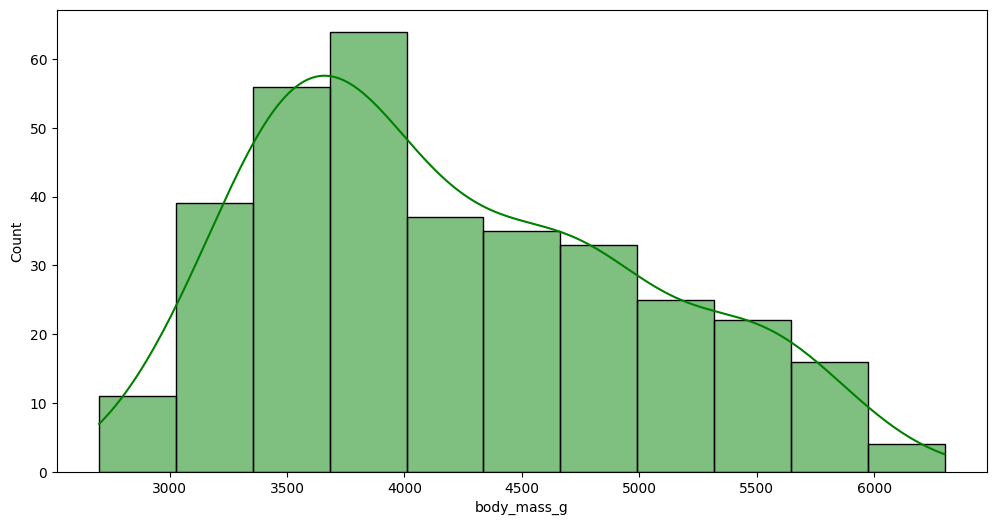

In [109]:
# Histograms of body mass (multimodal?)
plt.figure(figsize=(12,6))
sns.histplot(data=df,x="body_mass_g",kde=True,color="Green")
plt.show()

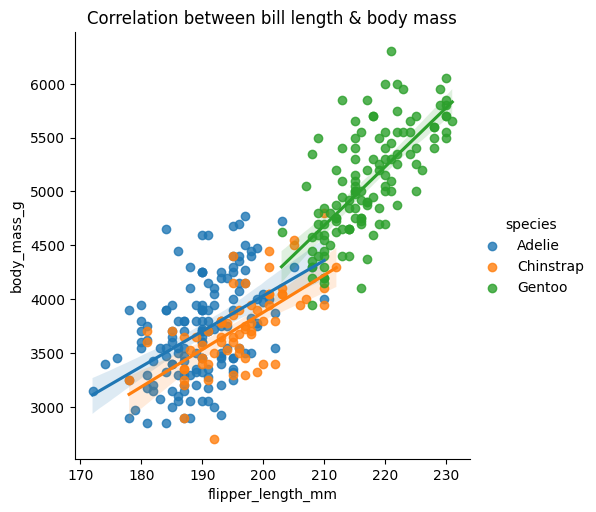

In [112]:
# Correlation between bill length & body mass
sns.lmplot(data=df,x="flipper_length_mm",y="body_mass_g",hue="species")
plt.title("Correlation between bill length & body mass")
plt.show()

<Axes: xlabel='species', ylabel='body_mass_g'>

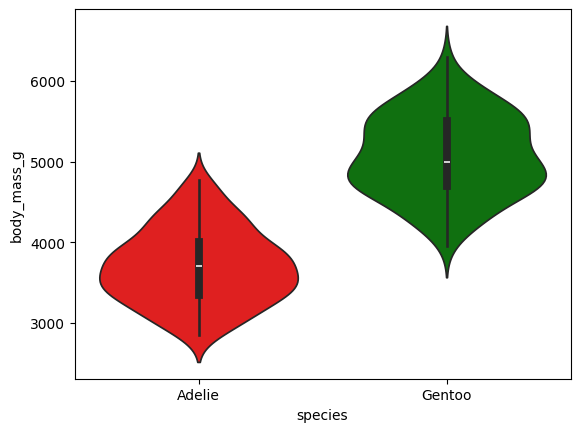

In [117]:
# Violin plots for Adelie vs Chinstrap

sns.violinplot(data=df[df["species"].isin(["Adelie","Gentoo"])],x="species",y="body_mass_g",palette=["Red","green"])

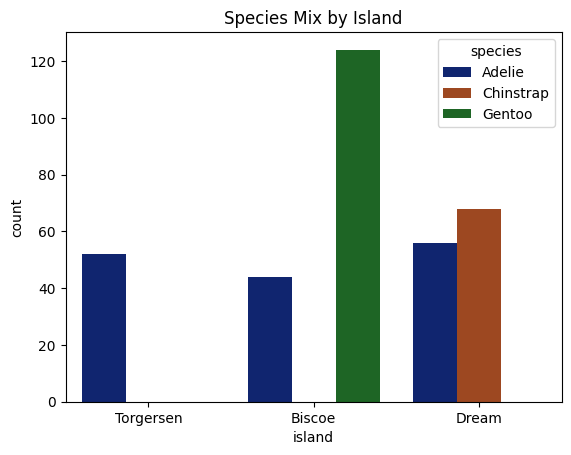

In [119]:
# Q19 Island with most diverse species mix
sns.countplot(x="island", hue="species", data=df, palette="dark")
plt.title("Species Mix by Island")
plt.show()

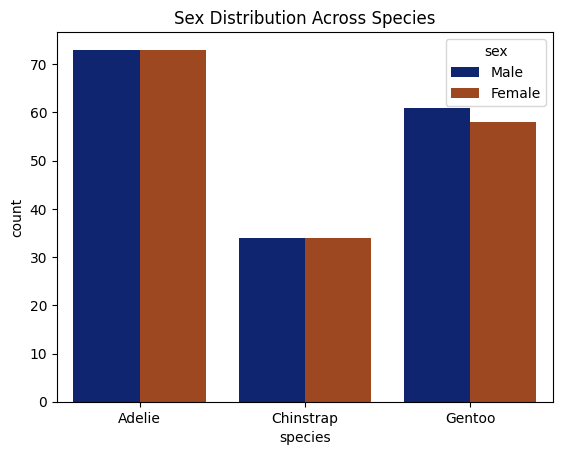

In [121]:
# Q20 Sex distribution differences across species
sns.countplot(x="species", hue="sex", data=df, palette="dark")
plt.title("Sex Distribution Across Species")
plt.show()